In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
path = "/content/gdrive/MyDrive/machine learning/praktikum/praktikum4"

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score
)

In [22]:
# Baca dataset
df = pd.read_csv(path + '/Data/calonpembelimobil.csv', sep=',')
df.head()

,ID,Usia,Status,Kelamin,Memiliki_Mobil,Penghasilan,Beli_Mobil
0,1,32,1,0,0,240,1
1,2,49,2,1,1,100,0
2,3,52,1,0,2,250,1
3,4,26,2,1,1,130,0
4,5,45,3,0,2,237,1


In [14]:
display(df.info())
print('\nMissing values per column:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ID              1000 non-null   int64
 1   Usia            1000 non-null   int64
 2   Status          1000 non-null   int64
 3   Kelamin         1000 non-null   int64
 4   Memiliki_Mobil  1000 non-null   int64
 5   Penghasilan     1000 non-null   int64
 6   Beli_Mobil      1000 non-null   int64
dtypes: int64(7)
memory usage: 54.8 KB


None


Missing values per column:
ID                0
Usia              0
Status            0
Kelamin           0
Memiliki_Mobil    0
Penghasilan       0
Beli_Mobil        0
dtype: int64


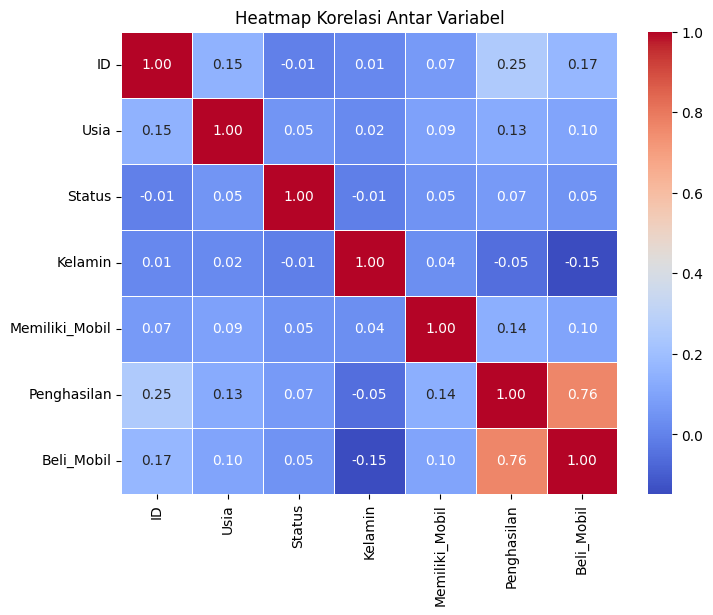

In [15]:
numeric_df = df.copy()
cat_cols = ['Status','Kelamin','Memiliki_Mobil']
for c in cat_cols:
    if c in numeric_df.columns:
        try:
            numeric_df[c] = pd.to_numeric(numeric_df[c])
        except:
            numeric_df[c] = numeric_df[c].astype('category').cat.codes

corr_matrix = numeric_df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Variabel')
plt.show()

In [16]:
feature_num = ['Usia', 'Penghasilan']
feature_cat = ['Status', 'Kelamin', 'Memiliki_Mobil']
all_features = feature_num + feature_cat

X = df[all_features].copy()
y = df['Beli_Mobil'].copy()

print('X shape:', X.shape)
print('y shape:', y.shape)
X.head()

X shape: (1000, 5)
y shape: (1000,)


,Usia,Penghasilan,Status,Kelamin,Memiliki_Mobil
0,32,240,1,0,0
1,49,100,2,1,1
2,52,250,1,0,2
3,26,130,2,1,1
4,45,237,3,0,2


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (800, 5) Test: (200, 5)


In [19]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), feature_num),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), feature_cat),
    ],
    remainder='drop'
)

model = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)

clf = Pipeline([
    ('preprocess', preprocess),
    ('model', model)
])

# Latih model
clf.fit(X_train, y_train)
print('✅ Model Logistic Regression berhasil dilatih.')

✅ Model Logistic Regression berhasil dilatih.


Accuracy: 0.935

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.91        73
           1       0.95      0.94      0.95       127

    accuracy                           0.94       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.94      0.94      0.94       200



<Figure size 500x400 with 0 Axes>

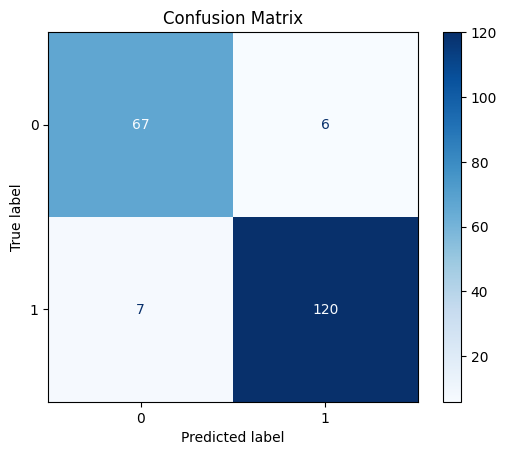

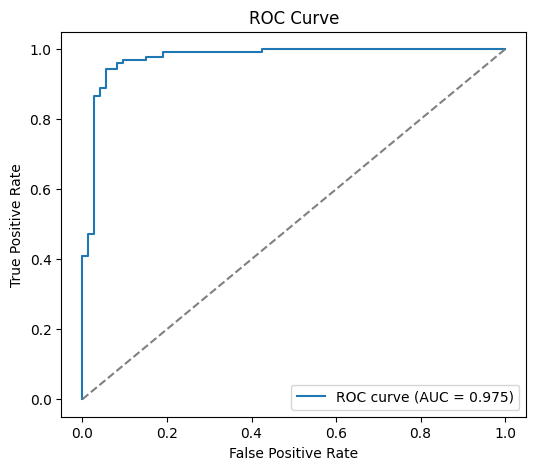

In [20]:
# Predict
y_pred = clf.predict(X_test)
y_proba = None
try:
    y_proba = clf.predict_proba(X_test)[:,1]
except Exception as e:
    print('predict_proba not available:', e)

# Metrics
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
if y_proba is not None:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()
else:
    print('Probabilities not available; ROC curve skipped')

In [21]:
data_baru = pd.DataFrame({
    'Usia':[28,45],
    'Penghasilan':[200,450],
    'Status':[1,2],
    'Kelamin':[0,1],
    'Memiliki_Mobil':[0,1]
})

prediksi = clf.predict(data_baru)
print('Data baru:')
display(data_baru)
print('Prediksi (Beli_Mobil):', prediksi)
try:
    print('Probabilitas (kelas=1):', clf.predict_proba(data_baru)[:,1])
except:
    pass

Data baru:


,Usia,Penghasilan,Status,Kelamin,Memiliki_Mobil
0,28,200,1,0,0
1,45,450,2,1,1


Prediksi (Beli_Mobil): [0 1]
Probabilitas (kelas=1): [0.43079615 0.99997232]
